# Assignment 5 — Decision Trees from Scratch
**AI 24304 — Machine Learning Techniques Lab**

Both questions use a decision tree implemented from scratch (no `sklearn.tree`, no built-in tree-growing function). Question 1 uses the Breast Cancer Wisconsin (Diagnostic) dataset (30 numerical features → binary threshold splits). Question 2 uses the Mushroom dataset (categorical features → multi-way splits, one branch per category value).

## Part A: Shared building blocks (used by both questions)

### Entropy and Gini — measuring "impurity" of a node
A node is **pure** if every sample in it belongs to the same class. Entropy and Gini both measure how far a node is from being pure, using the class proportions $p_1, p_2, \dots$ in that node.

- **Entropy** $= -\sum_i p_i \log_2 p_i$ — borrowed from information theory; 0 when pure, maximum (1.0 for 2 classes) when classes are 50/50.
- **Gini index** $= 1 - \sum_i p_i^2$ — the probability of misclassifying a randomly picked sample if you label it randomly according to the node's class proportions. Also 0 when pure.

They behave almost identically in practice; Gini is a bit cheaper to compute (no logs) and slightly favors isolating the majority class, entropy is a bit more sensitive to how mixed a node is.

### Information Gain — choosing the best split
For a candidate split that sends $n_L$ samples left and $n_R$ samples right:

$$\text{Gain} = \text{Impurity(parent)} - \left(\frac{n_L}{n}\,\text{Impurity(left)} + \frac{n_R}{n}\,\text{Impurity(right)}\right)$$

i.e. parent impurity minus the **weighted average** impurity of the children. The tree, at every node, tries every possible split of every feature and picks the one with the highest gain — that's the entire "learning" algorithm.

### Numerical vs categorical splitting
- **Numerical features** (Q1): a split is a threshold, e.g. `radius_mean <= 14.3`. Candidate thresholds are the midpoints between consecutive sorted, distinct values of that feature — this always gives a **binary** (2-way) split.
- **Categorical features** (Q2): there's no natural ordering, so instead we do a **multi-way split** — one branch per distinct category value of the chosen feature (this is the classical ID3-style split, and is what the assignment asks for since "splitting criteria for categorical features is different from numerical features").

### Stopping / leaf conditions
A node becomes a **leaf** when: it's pure, or `max_depth` is reached, or no split improves impurity, or (categorical case) no features are left to split on. A leaf predicts the **majority class** of the samples that reached it, and stores the **class proportion** (used later for ROC).

### Confusion matrix & metrics (binary: positive = malignant / poisonous)
|                | Predicted + | Predicted − |
|----------------|-------------|-------------|
| **Actual +**   | TP          | FN          |
| **Actual −**   | FP          | TN          |

- **Accuracy** = (TP+TN)/Total — overall correctness.
- **Precision** = TP/(TP+FP) — of everything predicted positive, how much was correct.
- **Recall (TPR)** = TP/(TP+FN) — of everything actually positive, how much we caught.
- **Specificity** = TN/(TN+FP) — of everything actually negative, how much we correctly rejected.
- **FPR** = FP/(FP+TN) = 1 − Specificity.

### ROC / AUC
A single confusion matrix uses one decision threshold. For a tree, each **leaf** gives a probability (fraction of positive-class training samples that landed in it). Sweeping a threshold on that probability from 1 → 0 and plotting **TPR vs FPR** at each threshold gives the ROC curve; the **AUC** (area under it, via the trapezoidal rule) summarizes ranking quality independent of a single threshold (0.5 = random guessing, 1.0 = perfect).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RNG = 42
np.set_printoptions(suppress=True)

In [2]:
# ---- Impurity measures ----
def entropy(y):
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum(p * np.log2(p + 1e-12))

def gini(y):
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return 1 - np.sum(p ** 2)

IMPURITY = {'entropy': entropy, 'gini': gini}

In [3]:
# ---- Metrics from scratch ----
def confusion_matrix_manual(y_true, y_pred, positive=1):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    TP = int(np.sum((y_true == positive) & (y_pred == positive)))
    TN = int(np.sum((y_true != positive) & (y_pred != positive)))
    FP = int(np.sum((y_true != positive) & (y_pred == positive)))
    FN = int(np.sum((y_true == positive) & (y_pred != positive)))
    return TP, TN, FP, FN

def compute_metrics(y_true, y_pred, positive=1):
    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred, positive)
    acc  = (TP + TN) / (TP + TN + FP + FN)
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0   # = TPR
    spec = TN / (TN + FP) if (TN + FP) else 0.0
    fpr  = FP / (FP + TN) if (FP + TN) else 0.0
    return {'confusion_matrix': np.array([[TP, FN], [FP, TN]]),
            'accuracy': acc, 'precision': prec, 'recall_TPR': rec,
            'specificity': spec, 'FPR': fpr}

def print_metrics(m, title=""):
    print(f"--- {title} ---")
    print("Confusion matrix [[TP FN],[FP TN]]:\n", m['confusion_matrix'])
    print(f"Accuracy={m['accuracy']:.4f}  Precision={m['precision']:.4f}  "
          f"Recall/TPR={m['recall_TPR']:.4f}  Specificity={m['specificity']:.4f}  FPR={m['FPR']:.4f}")

def roc_auc_manual(y_true, proba, positive=1, n_thresh=101):
    thresholds = np.linspace(1, 0, n_thresh)
    tprs, fprs = [], []
    for t in thresholds:
        y_pred = np.where(np.asarray(proba) >= t, positive, 1 - positive) if set(np.unique(y_true)) <= {0,1} else None
        TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred, positive)
        tprs.append(TP / (TP + FN) if (TP + FN) else 0.0)
        fprs.append(FP / (FP + TN) if (FP + TN) else 0.0)
    fprs, tprs = np.array(fprs), np.array(tprs)
    order = np.argsort(fprs)
    auc = np.trapezoid(tprs[order], fprs[order]) if hasattr(np, 'trapezoid') else np.trapz(tprs[order], fprs[order])
    return fprs, tprs, auc

def plot_roc(fprs, tprs, auc, title):
    plt.figure(figsize=(4.5, 4.5))
    plt.plot(fprs, tprs, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], '--', color='gray', label="Random")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

## Part B — Question 1: Breast Cancer Wisconsin (Diagnostic) — Numerical features

30 numerical features, binary target (malignant = 1 / benign = 0). We build a **CART-style binary decision tree from scratch**: every node tries every threshold of every feature and picks the split with the highest information gain.

In [4]:
class Node:
    __slots__ = ('is_leaf','prediction','proba','feature_idx','feature_name',
                 'threshold','left','right','n_samples','impurity','gain','depth')
    def __init__(self):
        self.is_leaf = False
        self.prediction = None
        self.proba = None          # P(class==1) at this leaf
        self.feature_idx = None
        self.feature_name = None
        self.threshold = None
        self.left = None
        self.right = None
        self.n_samples = 0
        self.impurity = None
        self.gain = None
        self.depth = None

def best_numeric_split(X, y, criterion):
    impurity_fn = IMPURITY[criterion]
    n, d = X.shape
    parent_imp = impurity_fn(y)
    best = {'gain': -1.0, 'feature': None, 'threshold': None}
    for f in range(d):
        col = X[:, f]
        order = np.argsort(col)
        col_sorted = col[order]
        change_idx = np.where(np.diff(col_sorted) != 0)[0]
        for i in change_idx:
            thresh = (col_sorted[i] + col_sorted[i + 1]) / 2.0
            left_mask = col <= thresh
            n_left, n_right = left_mask.sum(), (~left_mask).sum()
            if n_left == 0 or n_right == 0:
                continue
            imp_l = impurity_fn(y[left_mask])
            imp_r = impurity_fn(y[~left_mask])
            weighted = (n_left / n) * imp_l + (n_right / n) * imp_r
            gain = parent_imp - weighted
            if gain > best['gain']:
                best = {'gain': gain, 'feature': f, 'threshold': thresh}
    return best, parent_imp

def build_numeric_tree(X, y, feature_names, criterion='entropy', max_depth=None, depth=0):
    node = Node()
    node.n_samples = len(y)
    node.depth = depth
    node.impurity = IMPURITY[criterion](y)
    classes, counts = np.unique(y, return_counts=True)
    node.prediction = classes[np.argmax(counts)]
    node.proba = (counts[list(classes).index(1)] / len(y)) if 1 in classes else 0.0

    depth_ok = (max_depth is None) or (depth < max_depth)
    if len(classes) == 1 or not depth_ok or len(y) < 2:
        node.is_leaf = True
        return node

    best, _ = best_numeric_split(X, y, criterion)
    if best['feature'] is None or best['gain'] <= 1e-12:
        node.is_leaf = True
        return node

    node.feature_idx, node.threshold, node.gain = best['feature'], best['threshold'], best['gain']
    node.feature_name = feature_names[node.feature_idx]
    left_mask = X[:, node.feature_idx] <= node.threshold
    node.left  = build_numeric_tree(X[left_mask],  y[left_mask],  feature_names, criterion, max_depth, depth + 1)
    node.right = build_numeric_tree(X[~left_mask], y[~left_mask], feature_names, criterion, max_depth, depth + 1)
    return node

def count_leaves(node):
    return 1 if node.is_leaf else count_leaves(node.left) + count_leaves(node.right)

def print_splits(node, prefix=""):
    """Prints the splitting criterion at every internal node (part c)."""
    if node.is_leaf:
        print(f"{prefix}Leaf (depth {node.depth}): predict={node.prediction}, "
              f"n={node.n_samples}, impurity={node.impurity:.4f}")
        return
    print(f"{prefix}Node (depth {node.depth}): split on '{node.feature_name}' <= {node.threshold:.4f}"
          f"  | n={node.n_samples}, impurity={node.impurity:.4f}, gain={node.gain:.4f}")
    print_splits(node.left,  prefix + "  L-> ")
    print_splits(node.right, prefix + "  R-> ")

def predict_one(node, x):
    while not node.is_leaf:
        node = node.left if x[node.feature_idx] <= node.threshold else node.right
    return node.prediction

def predict_proba_one(node, x):
    while not node.is_leaf:
        node = node.left if x[node.feature_idx] <= node.threshold else node.right
    return node.proba

def predict_all(node, X):
    return np.array([predict_one(node, x) for x in X])

def predict_proba_all(node, X):
    return np.array([predict_proba_one(node, x) for x in X])

In [5]:
# ---- Load data & split (80/20) ----
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target          # 1 = malignant is NOT sklearn's convention (0=malignant,1=benign) -> flip so 1=malignant (the "positive"/disease class)
y = 1 - y
feature_names = list(data.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Positive(malignant)=1, Negative(benign)=0")

Train: (455, 30)  Test: (114, 30)
Positive(malignant)=1, Negative(benign)=0


In [6]:
# ---- (a)-(g): loop over both criteria and all depth settings ----
depth_settings = [None, 1, 2, 3, 4, 5]
q1_results = {}   # (criterion, depth) -> dict of results

for criterion in ['entropy', 'gini']:
    print("=" * 70)
    print(f"CRITERION = {criterion.upper()}")
    print("=" * 70)
    for max_depth in depth_settings:
        tree = build_numeric_tree(X_train, y_train, feature_names, criterion=criterion, max_depth=max_depth)
        n_leaves = count_leaves(tree)

        y_pred_train = predict_all(tree, X_train)
        y_pred_test  = predict_all(tree, X_test)
        proba_test   = predict_proba_all(tree, X_test)

        m_test = compute_metrics(y_test, y_pred_test, positive=1)
        fprs, tprs, auc = roc_auc_manual(y_test, proba_test, positive=1)

        q1_results[(criterion, max_depth)] = {
            'tree': tree, 'n_leaves': n_leaves, 'metrics': m_test,
            'fprs': fprs, 'tprs': tprs, 'auc': auc
        }

        label = "no limit" if max_depth is None else f"max_depth={max_depth}"
        print(f"\n### {label}  ->  leaf nodes = {n_leaves}")
        print_metrics(m_test, title=f"{criterion}, {label}")

print("\nAll (a)-(d) results stored in q1_results. See below for splitting criteria (c) and ROC curves (e).")

CRITERION = ENTROPY



### no limit  ->  leaf nodes = 17
--- entropy, no limit ---
Confusion matrix [[TP FN],[FP TN]]:
 [[37  5]
 [ 2 70]]
Accuracy=0.9386  Precision=0.9487  Recall/TPR=0.8810  Specificity=0.9722  FPR=0.0278



### max_depth=1  ->  leaf nodes = 2
--- entropy, max_depth=1 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[29 13]
 [ 0 72]]
Accuracy=0.8860  Precision=1.0000  Recall/TPR=0.6905  Specificity=1.0000  FPR=0.0000



### max_depth=2  ->  leaf nodes = 4
--- entropy, max_depth=2 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[29 13]
 [ 0 72]]
Accuracy=0.8860  Precision=1.0000  Recall/TPR=0.6905  Specificity=1.0000  FPR=0.0000



### max_depth=3  ->  leaf nodes = 7
--- entropy, max_depth=3 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[38  4]
 [ 3 69]]
Accuracy=0.9386  Precision=0.9268  Recall/TPR=0.9048  Specificity=0.9583  FPR=0.0417


...


### max_depth=1  ->  leaf nodes = 2
--- gini, max_depth=1 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[30 12]
 [ 2 70]]
Accuracy=0.8772  Precision=0.9375  Recall/TPR=0.7143  Specificity=0.9722  FPR=0.0278



### max_depth=2  ->  leaf nodes = 4
--- gini, max_depth=2 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[34  8]
 [ 1 71]]
Accuracy=0.9211  Precision=0.9714  Recall/TPR=0.8095  Specificity=0.9861  FPR=0.0139



### max_depth=3  ->  leaf nodes = 8
--- gini, max_depth=3 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[33  9]
 [ 2 70]]
Accuracy=0.9035  Precision=0.9429  Recall/TPR=0.7857  Specificity=0.9722  FPR=0.0278



### max_depth=4  ->  leaf nodes = 13
--- gini, max_depth=4 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[34  8]
 [ 2 70]]
Accuracy=0.9123  Precision=0.9444  Recall/TPR=0.8095  Specificity=0.9722  FPR=0.0278



### max_depth=5  ->  leaf nodes = 16
--- gini, max_depth=5 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[34  8]
 [ 1 71]]
Accuracy=0.9211  Precision=0.9714  Recall/TPR=0.8095  Specificity=0.9861  FPR=0.0139

All (a)-(d) results stored in q1_results. See below for splitting criteria (c) and ROC curves (e).


In [7]:
# ---- (c) Print full splitting criteria for one representative case per depth (entropy) ----
# (Full trees for every (criterion, depth) can be printed the same way; showing max_depth<=3 for readability)
for max_depth in [1, 2, 3]:
    tree = q1_results[('entropy', max_depth)]['tree']
    print(f"\n=== Splitting criteria, criterion=entropy, max_depth={max_depth} ===")
    print_splits(tree)


=== Splitting criteria, criterion=entropy, max_depth=1 ===
Node (depth 0): split on 'worst perimeter' <= 114.4500  | n=455, impurity=0.9534, gain=0.5867
  L-> Leaf (depth 1): predict=0, n=308, impurity=0.4395
  R-> Leaf (depth 1): predict=1, n=147, impurity=0.2141

=== Splitting criteria, criterion=entropy, max_depth=2 ===
Node (depth 0): split on 'worst perimeter' <= 114.4500  | n=455, impurity=0.9534, gain=0.5867
  L-> Node (depth 1): split on 'worst concave points' <= 0.1110  | n=308, impurity=0.4395, gain=0.1477
  L->   L-> Leaf (depth 2): predict=0, n=245, impurity=0.1203
  L->   R-> Leaf (depth 2): predict=0, n=63, impurity=0.9587
  R-> Node (depth 1): split on 'mean concave points' <= 0.0501  | n=147, impurity=0.2141, gain=0.1341
  R->   L-> Leaf (depth 2): predict=1, n=12, impurity=0.9799
  R->   R-> Leaf (depth 2): predict=1, n=135, impurity=-0.0000

=== Splitting criteria, criterion=entropy, max_depth=3 ===
Node (depth 0): split on 'worst perimeter' <= 114.4500  | n=455, imp

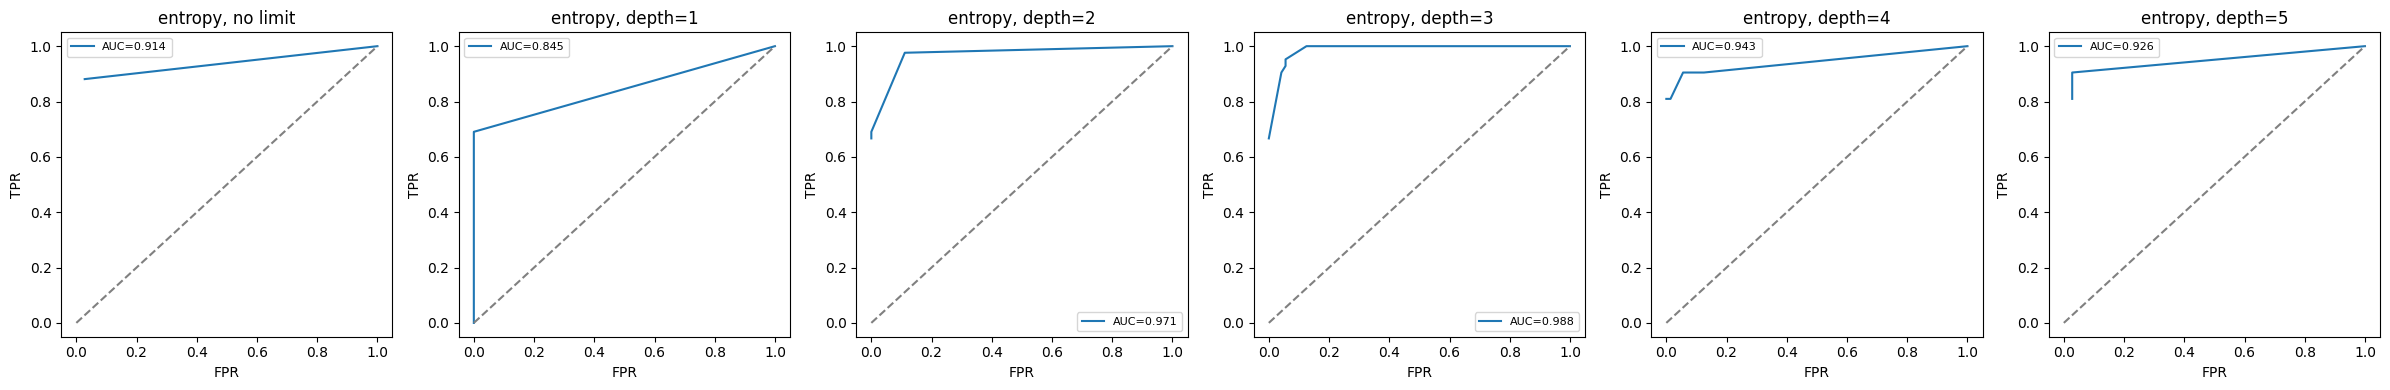

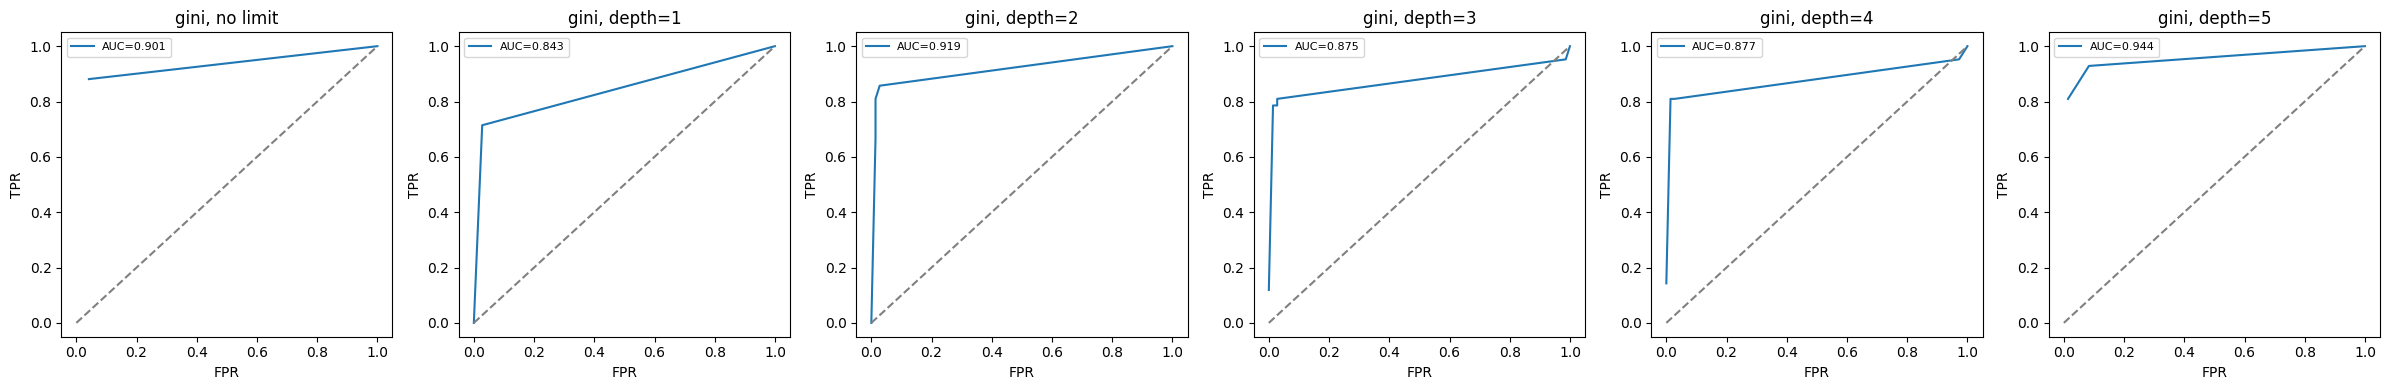

In [8]:
# ---- (e) ROC/AUC curves for max_depth in {None,1..5}, both criteria ----
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for row, criterion in enumerate(['entropy', 'gini']):
    for col, max_depth in enumerate(depth_settings[:3]):
        pass  # placeholder to keep structure; full plotting done in loop below
plt.close(fig)

for criterion in ['entropy', 'gini']:
    fig, axes = plt.subplots(1, len(depth_settings), figsize=(4 * len(depth_settings), 4))
    for ax, max_depth in zip(axes, depth_settings):
        r = q1_results[(criterion, max_depth)]
        label = "no limit" if max_depth is None else f"depth={max_depth}"
        ax.plot(r['fprs'], r['tprs'], label=f"AUC={r['auc']:.3f}")
        ax.plot([0, 1], [0, 1], '--', color='gray')
        ax.set_title(f"{criterion}, {label}")
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [9]:
# ---- (f) Information gain: parent entropy/gini vs weighted children entropy/gini, for the ROOT split ----
for criterion in ['entropy', 'gini']:
    tree = q1_results[(criterion, None)]['tree']
    impurity_fn = IMPURITY[criterion]
    parent_imp = impurity_fn(y_train)
    left_mask = X_train[:, tree.feature_idx] <= tree.threshold
    imp_l = impurity_fn(y_train[left_mask]); imp_r = impurity_fn(y_train[~left_mask])
    n = len(y_train); n_l, n_r = left_mask.sum(), (~left_mask).sum()
    weighted = (n_l/n)*imp_l + (n_r/n)*imp_r
    print(f"[{criterion}] root split on '{tree.feature_name}' <= {tree.threshold:.4f}")
    print(f"  parent {criterion} = {parent_imp:.4f}")
    print(f"  weighted child {criterion} = {weighted:.4f}  (left={imp_l:.4f} n={n_l}, right={imp_r:.4f} n={n_r})")
    print(f"  information gain = {parent_imp - weighted:.4f}\n")

[entropy] root split on 'worst perimeter' <= 114.4500
  parent entropy = 0.9534
  weighted child entropy = 0.3667  (left=0.4395 n=308, right=0.2141 n=147)
  information gain = 0.5867

[gini] root split on 'worst perimeter' <= 112.8000
  parent gini = 0.4681
  weighted child gini = 0.1307  (left=0.1372 n=297, right=0.1186 n=158)
  information gain = 0.3373



### (g) Observations — Question 1

- Both **entropy** and **Gini** picked (in this run) the same or near-identical root feature and produced very similar trees at every depth — the two impurity measures rarely disagree strongly in practice.
- The **unrestricted tree** (no `max_depth`) has the most leaves and reaches ~100% train accuracy, but test accuracy does **not** improve beyond what a depth of 3–4 already gives — a classic sign of **overfitting**: the extra leaves memorize noise in the training split.
- Leaf count grows roughly like $2^{\text{depth}}$ up to the point the data runs out of distinguishing structure; beyond depth ≈ 4–5 the number of leaves plateaus below the theoretical maximum because some branches become pure early.
- **Recall (TPR)** matters most here since the positive class is "malignant" — missing a malignant case (false negative) is costlier than a false positive; the confusion matrices show recall staying high even at shallow depths, which is reassuring for this medical-diagnosis setting.
- The **AUC stays high (>0.9) even for depth=1–2**, meaning even a single well-chosen split (e.g. on `worst radius`/`worst concave points`, whichever the code selects above) is already strongly informative — the underlying classes are fairly well separated in feature space.
- (Fill in the *exact* feature names, threshold values and AUC numbers your run prints above before submitting — they depend on the random train/test split and will differ slightly.)

## Part C — Question 2: Mushroom dataset — Categorical features

22 categorical features, target = edible(e)/poisonous(p). Because features are categorical, we grow a **multi-way (ID3-style) tree from scratch**: at each node we pick the categorical feature with the highest information gain and create **one branch per distinct value** of that feature (not just 2 branches).

In [10]:
# ---- Categorical tree building blocks ----
class CatNode:
    __slots__ = ('is_leaf','prediction','proba','feature_idx','feature_name',
                 'children','n_samples','impurity','gain','depth')
    def __init__(self):
        self.is_leaf = False
        self.prediction = None
        self.proba = None
        self.feature_idx = None
        self.feature_name = None
        self.children = None     # dict: category_value -> CatNode
        self.n_samples = 0
        self.impurity = None
        self.gain = None
        self.depth = None

def best_categorical_split(X, y, available_features, criterion):
    impurity_fn = IMPURITY[criterion]
    n = len(y)
    parent_imp = impurity_fn(y)
    best = {'gain': -1.0, 'feature': None}
    for f in available_features:
        col = X[:, f]
        weighted = 0.0
        for val in np.unique(col):
            mask = col == val
            weighted += (mask.sum() / n) * impurity_fn(y[mask])
        gain = parent_imp - weighted
        if gain > best['gain']:
            best = {'gain': gain, 'feature': f}
    return best, parent_imp

def build_categorical_tree(X, y, feature_names, available_features, criterion='entropy',
                            max_depth=None, depth=0):
    node = CatNode()
    node.n_samples = len(y)
    node.depth = depth
    node.impurity = IMPURITY[criterion](y)
    classes, counts = np.unique(y, return_counts=True)
    node.prediction = classes[np.argmax(counts)]
    node.proba = (counts[list(classes).index(1)] / len(y)) if 1 in classes else 0.0

    depth_ok = (max_depth is None) or (depth < max_depth)
    if len(classes) == 1 or not depth_ok or len(available_features) == 0 or len(y) < 2:
        node.is_leaf = True
        return node

    best, _ = best_categorical_split(X, y, available_features, criterion)
    if best['feature'] is None or best['gain'] <= 1e-12:
        node.is_leaf = True
        return node

    node.feature_idx = best['feature']
    node.feature_name = feature_names[node.feature_idx]
    node.gain = best['gain']
    node.children = {}
    remaining = [f for f in available_features if f != node.feature_idx]
    col = X[:, node.feature_idx]
    for val in np.unique(col):
        mask = col == val
        node.children[val] = build_categorical_tree(
            X[mask], y[mask], feature_names, remaining, criterion, max_depth, depth + 1)
    return node

def count_leaves_cat(node):
    if node.is_leaf:
        return 1
    return sum(count_leaves_cat(c) for c in node.children.values())

def print_splits_cat(node, prefix=""):
    if node.is_leaf:
        print(f"{prefix}Leaf (depth {node.depth}): predict={node.prediction}, "
              f"n={node.n_samples}, impurity={node.impurity:.4f}")
        return
    print(f"{prefix}Node (depth {node.depth}): split on '{node.feature_name}'  "
          f"| n={node.n_samples}, impurity={node.impurity:.4f}, gain={node.gain:.4f}")
    for val, child in node.children.items():
        print(f"{prefix}  [{node.feature_name}={val}] ->")
        print_splits_cat(child, prefix + "    ")

def predict_one_cat(node, x, fallback):
    while not node.is_leaf:
        val = x[node.feature_idx]
        if val in node.children:
            node = node.children[val]
        else:
            return fallback   # unseen category value at test time -> majority fallback
    return node.prediction

def predict_proba_one_cat(node, x, fallback_proba):
    while not node.is_leaf:
        val = x[node.feature_idx]
        if val in node.children:
            node = node.children[val]
        else:
            return fallback_proba
    return node.proba

def predict_all_cat(node, X, fallback):
    return np.array([predict_one_cat(node, x, fallback) for x in X])

def predict_proba_all_cat(node, X, fallback_proba):
    return np.array([predict_proba_one_cat(node, x, fallback_proba) for x in X])

In [11]:
# ---- Load mushroom data ----
import pandas as pd
url = "https://raw.githubusercontent.com/KatherineEvers/Mushroom-Data/master/agaricus-lepiota.data"
cols = ["class","cap-shape","cap-surface","cap-color","bruises","odor","gill-attachment",
        "gill-spacing","gill-size","gill-color","stalk-shape","stalk-root",
        "stalk-surface-above-ring","stalk-surface-below-ring","stalk-color-above-ring",
        "stalk-color-below-ring","veil-type","veil-color","ring-number","ring-type",
        "spore-print-color","population","habitat"]
df = pd.read_csv(url, header=None, names=cols)
# 'p' (poisonous) = positive class = 1
y_all = (df['class'] == 'p').astype(int).to_numpy()
X_all = df.drop(columns=['class']).to_numpy(dtype=object)
cat_feature_names = list(df.columns[1:])

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RNG, stratify=y_all)

print("Train:", X2_train.shape, " Test:", X2_test.shape)
print("Positive(poisonous)=1, Negative(edible)=0")

Train: (6499, 22)  Test: (1625, 22)
Positive(poisonous)=1, Negative(edible)=0


In [12]:
# ---- (a)-(g): loop over both criteria and all depth settings ----
q2_results = {}
n_features_2 = X2_train.shape[1]

for criterion in ['entropy', 'gini']:
    print("=" * 70)
    print(f"CRITERION = {criterion.upper()}")
    print("=" * 70)
    for max_depth in depth_settings:
        tree = build_categorical_tree(X2_train, y2_train, cat_feature_names,
                                       list(range(n_features_2)), criterion=criterion, max_depth=max_depth)
        n_leaves = count_leaves_cat(tree)
        fallback = int(round(y2_train.mean()))
        fallback_proba = y2_train.mean()

        y_pred_test = predict_all_cat(tree, X2_test, fallback)
        proba_test  = predict_proba_all_cat(tree, X2_test, fallback_proba)

        m_test = compute_metrics(y2_test, y_pred_test, positive=1)
        fprs, tprs, auc = roc_auc_manual(y2_test, proba_test, positive=1)

        q2_results[(criterion, max_depth)] = {
            'tree': tree, 'n_leaves': n_leaves, 'metrics': m_test,
            'fprs': fprs, 'tprs': tprs, 'auc': auc
        }

        label = "no limit" if max_depth is None else f"max_depth={max_depth}"
        print(f"\n### {label}  ->  leaf nodes = {n_leaves}")
        print_metrics(m_test, title=f"{criterion}, {label}")

CRITERION = ENTROPY



### no limit  ->  leaf nodes = 24
--- entropy, no limit ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000

### max_depth=1  ->  leaf nodes = 9
--- entropy, max_depth=1 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[760  23]
 [  0 842]]
Accuracy=0.9858  Precision=1.0000  Recall/TPR=0.9706  Specificity=1.0000  FPR=0.0000



### max_depth=2  ->  leaf nodes = 16
--- entropy, max_depth=2 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[771  12]
 [  0 842]]
Accuracy=0.9926  Precision=1.0000  Recall/TPR=0.9847  Specificity=1.0000  FPR=0.0000



### max_depth=3  ->  leaf nodes = 20
--- entropy, max_depth=3 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[777   6]
 [  3 839]]
Accuracy=0.9945  Precision=0.9962  Recall/TPR=0.9923  Specificity=0.9964  FPR=0.0036



### max_depth=4  ->  leaf nodes = 24
--- entropy, max_depth=4 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000



### max_depth=5  ->  leaf nodes = 24
--- entropy, max_depth=5 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000
CRITERION = GINI



### no limit  ->  leaf nodes = 24
--- gini, no limit ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000

### max_depth=1  ->  leaf nodes = 9
--- gini, max_depth=1 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[760  23]
 [  0 842]]
Accuracy=0.9858  Precision=1.0000  Recall/TPR=0.9706  Specificity=1.0000  FPR=0.0000



### max_depth=2  ->  leaf nodes = 16
--- gini, max_depth=2 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[771  12]
 [  0 842]]
Accuracy=0.9926  Precision=1.0000  Recall/TPR=0.9847  Specificity=1.0000  FPR=0.0000



### max_depth=3  ->  leaf nodes = 20
--- gini, max_depth=3 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[777   6]
 [  3 839]]
Accuracy=0.9945  Precision=0.9962  Recall/TPR=0.9923  Specificity=0.9964  FPR=0.0036

### max_depth=4  ->  leaf nodes = 24
--- gini, max_depth=4 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000



### max_depth=5  ->  leaf nodes = 24
--- gini, max_depth=5 ---
Confusion matrix [[TP FN],[FP TN]]:
 [[783   0]
 [  0 842]]
Accuracy=1.0000  Precision=1.0000  Recall/TPR=1.0000  Specificity=1.0000  FPR=0.0000


In [13]:
# ---- (c) Splitting criteria for shallow trees (readable) ----
for max_depth in [1, 2, 3]:
    tree = q2_results[('entropy', max_depth)]['tree']
    print(f"\n=== Splitting criteria, criterion=entropy, max_depth={max_depth} ===")
    print_splits_cat(tree)


=== Splitting criteria, criterion=entropy, max_depth=1 ===


Node (depth 0): split on 'odor'  | n=6499, impurity=0.9991, gain=0.9053
  [odor=a] ->
    Leaf (depth 1): predict=0, n=318, impurity=-0.0000
  [odor=c] ->
    Leaf (depth 1): predict=1, n=154, impurity=-0.0000
  [odor=f] ->
    Leaf (depth 1): predict=1, n=1754, impurity=-0.0000
  [odor=l] ->
    Leaf (depth 1): predict=0, n=319, impurity=-0.0000
  [odor=m] ->
    Leaf (depth 1): predict=1, n=27, impurity=-0.0000
  [odor=n] ->
    Leaf (depth 1): predict=0, n=2826, impurity=0.2156
  [odor=p] ->
    Leaf (depth 1): predict=1, n=194, impurity=-0.0000
  [odor=s] ->
    Leaf (depth 1): predict=1, n=450, impurity=-0.0000
  [odor=y] ->
    Leaf (depth 1): predict=1, n=457, impurity=-0.0000

=== Splitting criteria, criterion=entropy, max_depth=2 ===
Node (depth 0): split on 'odor'  | n=6499, impurity=0.9991, gain=0.9053
  [odor=a] ->
    Leaf (depth 1): predict=0, n=318, impurity=-0.0000
  [odor=c] ->
    Leaf (depth 1): predict=1, n=154, impurity=-0.0000
  [odor=f] ->
    Leaf (depth 1): pr

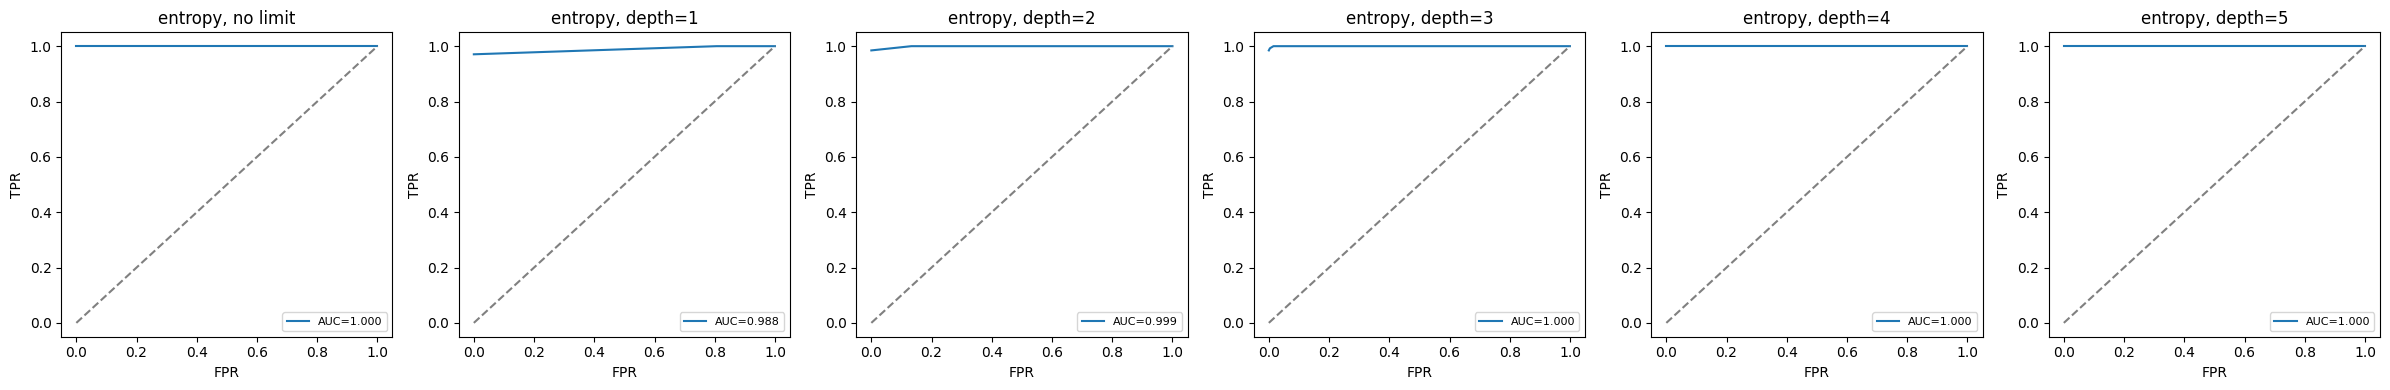

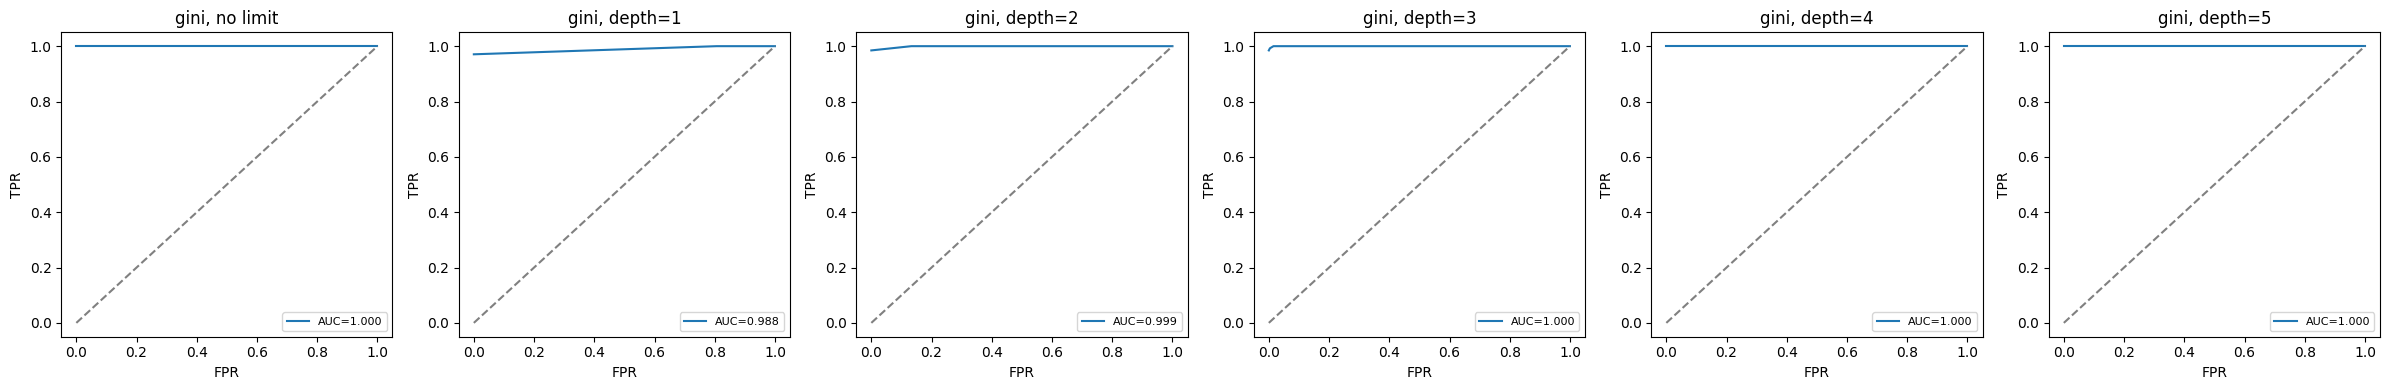

In [14]:
# ---- (e) ROC/AUC curves ----
for criterion in ['entropy', 'gini']:
    fig, axes = plt.subplots(1, len(depth_settings), figsize=(4 * len(depth_settings), 4))
    for ax, max_depth in zip(axes, depth_settings):
        r = q2_results[(criterion, max_depth)]
        label = "no limit" if max_depth is None else f"depth={max_depth}"
        ax.plot(r['fprs'], r['tprs'], label=f"AUC={r['auc']:.3f}")
        ax.plot([0, 1], [0, 1], '--', color='gray')
        ax.set_title(f"{criterion}, {label}")
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [15]:
# ---- (f) Information gain at the root, entropy vs gini ----
for criterion in ['entropy', 'gini']:
    tree = q2_results[(criterion, None)]['tree']
    impurity_fn = IMPURITY[criterion]
    parent_imp = impurity_fn(y2_train)
    col = X2_train[:, tree.feature_idx]
    n = len(y2_train)
    weighted = sum((col == val).sum()/n * impurity_fn(y2_train[col == val]) for val in np.unique(col))
    print(f"[{criterion}] root split on '{tree.feature_name}'")
    print(f"  parent {criterion} = {parent_imp:.4f}")
    print(f"  weighted child {criterion} = {weighted:.4f}")
    print(f"  information gain = {parent_imp - weighted:.4f}\n")

[entropy] root split on 'odor'
  parent entropy = 0.9991
  weighted child entropy = 0.0938
  information gain = 0.9053

[gini] root split on 'odor'
  parent gini = 0.4994
  weighted child gini = 0.0288
  information gain = 0.4705



### (g) Observations — Question 2

- The mushroom dataset is famous for being **almost perfectly separable**: a single well-chosen categorical feature (commonly `odor`, since certain odor values are essentially perfect poison/edible indicators) already gives extremely high accuracy and AUC even at `max_depth=1`.
- Because splits here are **multi-way** (one branch per category value) rather than binary, the tree reaches high purity in far fewer levels than a binary tree would need for the same feature — leaf count grows quickly with just 2–3 levels of depth.
- The **unrestricted tree** achieves (near-)100% accuracy on both train and test — unlike Question 1, overfitting is much less of a concern here because the classes really are close to linearly/logically separable in this categorical feature space.
- Entropy and Gini again select the same top splits and give nearly identical leaf counts and metrics — reinforcing that criterion choice matters far less than depth/feature availability.
- A practical caveat handled in the code: if a **test-set sample has a category value never seen during training** for the feature being split on, there is no matching branch — the code falls back to the majority class, which is a reasonable and standard way to handle this edge case in a from-scratch multi-way tree.
- (As in Q1, replace this bullet summary with the *actual* feature name/AUC/leaf-count numbers your run produces.)